In [63]:
import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import itertools

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten, Activation
from keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from keras.callbacks import EarlyStopping
from keras.callbacks import CSVLogger
from keras.callbacks import ProgbarLogger

In [64]:
#Prepare the data for triplet model
features = np.load('group16_features.npz', allow_pickle=False) #preprocessed features


#training data, the extracted features + the preprocessed images
#hog_features
hog_train = features["hog_train"]
hog_test = features["hog_test"]
#SIFT features
sift_train = features["sift_train"]
sift_test = features["sift_test"]
#PCA features
pca_train = features["pca_train"]
pca_test = features["pca_test"]
#fused features
fused_train = np.hstack([hog_train,sift_train])
fused_test = np.hstack([hog_test,sift_test])




#original images
images_train = np.load('./kaggle/working/prepped_data/train_X.npy', allow_pickle=False)
#images_train2 = np.concatenate((images_train,images_train[:, :, ::-1, :]),axis=0)
images_test = np.load('./kaggle/working/prepped_data/test_X.npy', allow_pickle=False)

labels = features["train_y"] #fetch the labels
if(np.size(hog_train,axis=0) >=80):
    labels = np.concatenate([labels,labels],axis=0)
    pca_train = np.concatenate([pca_train,pca_train],axis=0)


#Put the features in the correct data containers (format: hog_features,sift_features,PCA_features)
class_0_features = [hog_train[labels == 0], sift_train[labels == 0], pca_train[labels == 0]] #Jesse
class_1_features = [hog_train[labels == 1], sift_train[labels == 1], pca_train[labels == 1]] #Mila
class_2_features = [hog_train[labels == 2], sift_train[labels == 2], pca_train[labels == 2]] #Lookalikes
#A pre-specified percentage of these features will be used as our validation set, make the split before combining features into A,P,N
def make_split(data,percentage,mirrored_flag = False):
    #get the length of the data
    if(mirrored_flag):
        n = np.size(data[0],axis=0)//2
    else:
        n =  np.size(data[0],axis=0)
    #generate indices 
    base_indices = np.arange(n)
    train_base, val_base = train_test_split(
        base_indices,
        test_size=percentage,
        random_state=42,
        shuffle=True
    )
    if(mirrored_flag):
        train_indices = np.concatenate([train_base, train_base + n],axis=0)
        val_indices   = np.concatenate([val_base, val_base + n])
    else:
        train_indices = train_base
        val_indices   = val_base

    return  [arr[train_indices] for arr in data], [arr[val_indices] for arr in data]
#Split each of the classes into training and validation data
class_0_train, class_0_val = make_split(class_0_features,0.2,False)
class_1_train, class_1_val = make_split(class_1_features,0.2,False)
class_2_train, class_2_val = make_split(class_2_features,0.2,False)
#Concatenate the validation data and testdata into one large set
data_val = [np.concatenate([class_0_val[0],class_1_val[0],class_2_val[0]]),np.concatenate([class_0_val[1],class_1_val[1],class_2_val[1]]),np.concatenate([class_0_val[2],class_1_val[2],class_2_val[2]])]
data_test = [hog_test,sift_test,pca_test]

#Convert training data to zip format
class_0_train = list(zip(*class_0_train))
class_1_train = list(zip(*class_1_train))
class_2_train = list(zip(*class_2_train))



In [ ]:
#AI generated code for creating batches, this works for a standard set of feautres, fuse if you want to combine features
def triplet_batch_generator(X, y, batch_size):

    
    def augment(x):
        noise = np.random.normal(0, 0.01, size=x.shape)
        scale = np.random.uniform(0.9, 1.1)
        return x * scale + noise

    # Separate indices by class
    idx_p1 = np.where(y == 1)[0]
    idx_p2 = np.where(y == 2)[0]
    idx_lookalike = np.where(y == 0)[0]

    while True:
        A_batch, P_batch, N_batch = [], [], []

        for _ in range(batch_size):
            # Anchor: pick from Person1 or Person2
            anchor_class = np.random.choice([0, 1])
            anchor_idx = np.random.choice(idx_p1 if anchor_class == 0 else idx_p2)
            anchor = X[anchor_idx]
            #anchor = augment(anchor)

            # Positive: another image of same person
            pos_pool = idx_p1 if anchor_class == 0 else idx_p2
            pos_pool = pos_pool[pos_pool != anchor_idx]  # avoid same image
            positive_idx = np.random.choice(pos_pool)
            positive = X[positive_idx]
            #positive = augment(positive)

            # Negative: 50% chance easy (other person), 50% hard (lookalike)
            if np.random.rand() < 0.2:
                neg_pool = idx_p2 if anchor_class == 0 else idx_p1
            else:
                neg_pool = idx_lookalike
            negative_idx = np.random.choice(neg_pool)
            negative = X[negative_idx]
            #negative = augment(negative)

            # Add to batch
            A_batch.append(anchor)
            P_batch.append(positive)
            N_batch.append(negative)

        # Convert to arrays
        A_batch = np.stack(A_batch, axis=0)
        P_batch = np.stack(P_batch, axis=0)
        N_batch = np.stack(N_batch, axis=0)

        # dummy labels (ignored by loss)
        dummy_labels = np.zeros((batch_size,))

        yield (A_batch, P_batch, N_batch), dummy_labels

In [66]:
"""
#Now that we have semi-prepped the data, we can try to construct [A,P,N] triplets
#Anchor and positive will always be the same class, Negative will always originate from the lookalikes class
combinations = list(itertools.permutations(list(zip(*class_0_train)),2))
A_P = [[t1, t2] for t1, t2 in combinations]
print(type(A_P[0]))

combinations_2 = list(itertools.permutations(list(zip(*class_1_train)),2))
A_P += [[t1, t2] for t1, t2 in combinations_2]
#A_P += list(itertools.permutations(list(zip(*class_1_features)),2))

c_2 = list(zip(*class_2_train))
A_P_N = []

for pair in A_P:  # each pair is already a list of 2 triplets
    for triplet in c_2:
        # Create a new list starting with the 2 triplets from the pair and adding the new triplet
        A_P_N.append([pair[0], pair[1], triplet])
        
#this leads to 166.980 entries in the training set, I maybe should also add some easier combo's here
#We also kind of want to combine the class 1 with class 0 :(

#So really we should have [(idx,class_0 || class_1),(idx, class_0 || class_1),(idx, class_2 || class_1 || class_0)]
"""







"\n#Now that we have semi-prepped the data, we can try to construct [A,P,N] triplets\n#Anchor and positive will always be the same class, Negative will always originate from the lookalikes class\ncombinations = list(itertools.permutations(list(zip(*class_0_train)),2))\nA_P = [[t1, t2] for t1, t2 in combinations]\nprint(type(A_P[0]))\n\ncombinations_2 = list(itertools.permutations(list(zip(*class_1_train)),2))\nA_P += [[t1, t2] for t1, t2 in combinations_2]\n#A_P += list(itertools.permutations(list(zip(*class_1_features)),2))\n\nc_2 = list(zip(*class_2_train))\nA_P_N = []\n\nfor pair in A_P:  # each pair is already a list of 2 triplets\n    for triplet in c_2:\n        # Create a new list starting with the 2 triplets from the pair and adding the new triplet\n        A_P_N.append([pair[0], pair[1], triplet])\n\n#this leads to 166.980 entries in the training set, I maybe should also add some easier combo's here\n#We also kind of want to combine the class 1 with class 0 :(\n\n#So really we

In [67]:
def HOG_embedding_model(input_shape=(100,1),embedding_dim=64):

    #embedding_dim param determines the length of the vector we will use to represent our images
    #The model for one of the branches in the triplet model, (parameters should be tied)
    ##############################
    #Bottom branch implementation
    ##############################
    input_HOG = tf.keras.layers.Input(shape=input_shape,name="HOG_features")

    x = tf.keras.layers.Flatten()(input_HOG)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(embedding_dim)(x)

    # normalize embedding
    output = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

    model = tf.keras.Model(inputs=[input_HOG], outputs=output)

    return model

def build_triplet_model(embedding_model ,input_shape=(100,1)):
    #the model combining lookalikes and the original classes to produce anchors, positives and negatives

    input_A = tf.keras.layers.Input(shape=input_shape, name="anchor")
    input_P = tf.keras.layers.Input(shape=input_shape, name="positive")
    input_N = tf.keras.layers.Input(shape=input_shape, name="negative")

    zA = embedding_model(input_A)
    zP = embedding_model(input_P)
    zN = embedding_model(input_N)

    # concatenate for loss computation
    output = tf.keras.layers.Concatenate(axis=1)([zA, zP, zN])

    model = tf.keras.Model(
        inputs=[input_A, input_P, input_N],
        outputs=output
    )

    return model

def triplet_loss(margin=0.5):

    def loss(y_true, y_pred):
        # split embeddings
        dim = y_pred.shape[1] // 3

        zA = y_pred[:, 0:dim]
        zP = y_pred[:, dim:2*dim]
        zN = y_pred[:, 2*dim:3*dim]

        # distances
        d_pos = tf.reduce_sum(tf.square(zA - zP), axis=1)
        d_neg = tf.reduce_sum(tf.square(zA - zN), axis=1)

        # triplet loss
        return tf.reduce_mean(tf.maximum(0.0, d_pos - d_neg + margin))

    return loss

In [68]:
# -----------------------------
# 7. Build models
# -----------------------------
#Try for HOG first
embedding_dim = 64
shape = np.size(fused_train,axis=1)
margin = 0.5





embedding_model = HOG_embedding_model(input_shape=(shape,1), embedding_dim=embedding_dim)
triplet_model = build_triplet_model(embedding_model, input_shape=(shape,1))

triplet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss=triplet_loss(margin=margin))

triplet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 6042, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 6042, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 6042, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_12       │ (None, 64)        │  1,612,328 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 192)       │          0 │ functional_12[0]… │
│ (Concatenate)       │                   │            │ functional_12[1]… │
│                     │                   │            │ functional_12[2]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,612,328 (6.15 MB)

 Trainable params: 1,600,244 (6.10 MB)

 Non-trainable params: 12,084 (47.20 KB)

In [69]:
# -----------------------------
# 8. Train using generator
# -----------------------------
train_gen = triplet_batch_generator(fused_train, labels, batch_size=32)

early_stop = EarlyStopping(
    monitor='loss',       # or val_loss if you add validation
    patience=5,
    restore_best_weights=True
)

triplet_model.fit(
    train_gen,
    steps_per_epoch=30,
    epochs=100,
    callbacks=[early_stop]
)

embeddings = embedding_model.predict(fused_train)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1474
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0766
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0717
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0688
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0674
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0652
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0636
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0614
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0601
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0582
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0561
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0542
Epoch 13/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0522
Epoch 14/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0507
Epoch 15/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - lo

In [70]:
embeddings_test = embedding_model.predict(fused_test)

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}
gs = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted'
)
gs.fit(embeddings, labels)
clf = gs.best_estimator_
print(f"Best SVM params: {gs.best_params_}")

y_pred = clf.predict(embeddings_test)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best SVM params: {'C': 0.1, 'gamma': 'scale'}


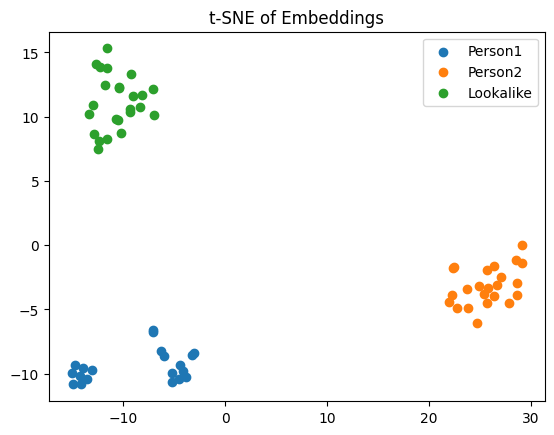

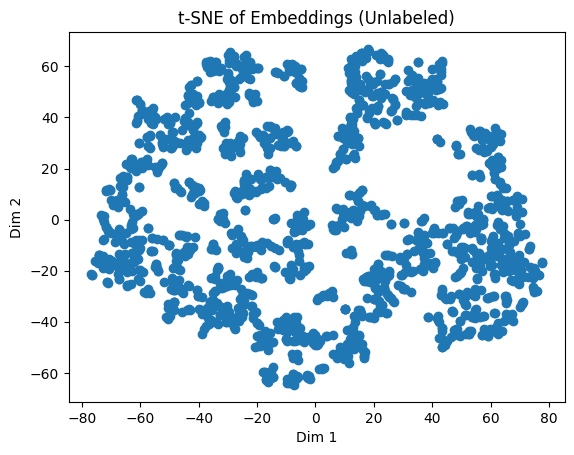

In [71]:
from sklearn.manifold import TSNE

def plot_tsne_embeddings(embeddings, labels):
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure()

    for cls, name in zip([0,1,2], ["Person1", "Person2", "Lookalike"]):
        idx = labels == cls
        plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=name)

    plt.legend()
    plt.title("t-SNE of Embeddings")
    plt.show()

# call
plot_tsne_embeddings(embeddings, labels)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_unlabeled(embeddings, perplexity=10, random_state=42):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init='pca',
        learning_rate='auto'
    )

    emb_2d = tsne.fit_transform(embeddings)

    plt.figure()
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1])
    plt.title("t-SNE of Embeddings (Unlabeled)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

# call
plot_tsne_unlabeled(embeddings_test)

In [72]:
test = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')


#  1. Generate final predictions using the pipeline
# This automatically extracts features from test_X and classifies them
test_y_star = y_pred

# 2. Prepare the submission dataframe
# Assuming 'test' is the original dataframe containing image info
submission = test.copy().drop('img', axis=1)
submission['class'] = test_y_star

# 3. Save to CSV for Kaggle upload
submission.to_csv('submission.csv', index=True)
print("✅ Final submission.csv created!")
submission.head()

✅ Final submission.csv created!


,class
id,
0,1
1,0
2,0
3,2
4,1
